In [3]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, activations, losses, metrics, optimizers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [5]:
dataset = pd.read_csv('dataset/data.csv')

X = np.array([np.array(row).reshape(28, 28, 1) for i, row in dataset.drop(columns=['label']).iterrows()])
y = np.array(dataset.label)
X.shape, y.shape

((42000, 28, 28, 1), (42000,))

  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  46 108 108  79   0   0   0   0   0   0   0   0
  0   0   0   0   0   0   0   0   0   0   0   0  10  94 164 229 238 253 253 246 199  80   0   0   0   0   0   0
  0   0   0   0   0   0   0   0   0   0  18 102 218 253 253 254 253 181 173 237 253 247 129  34   0   0   0   0
  0   0   0   0   0   0   0   0   0  18 107 253 253 253 218 187  59   6   0  42  81 232 253 212   0   0 

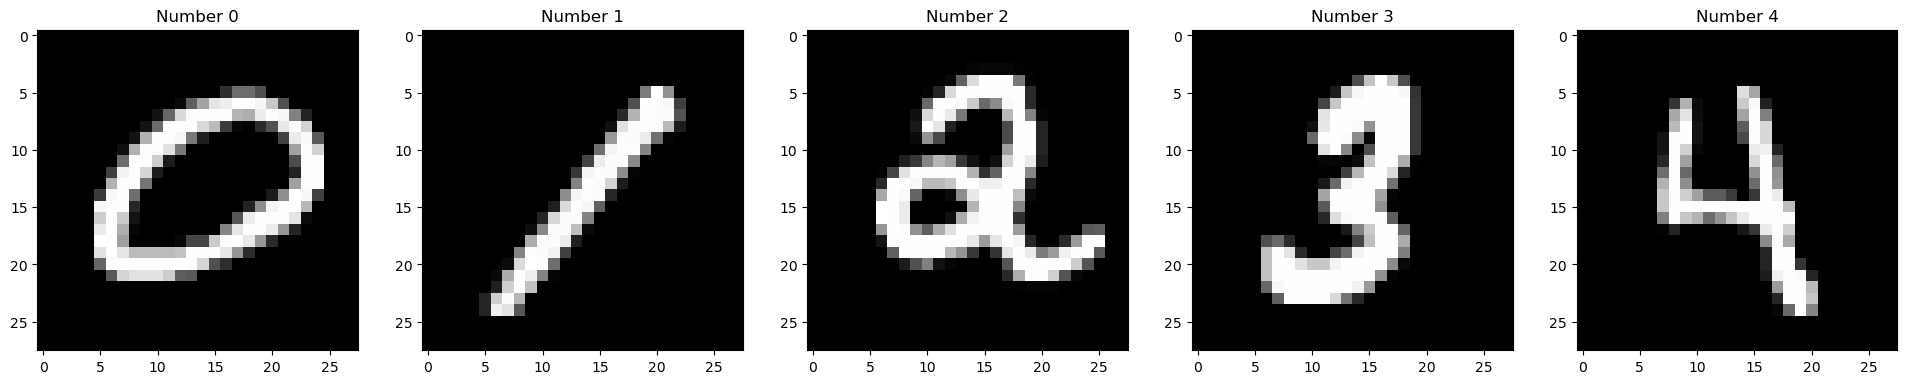

In [25]:
fig, axs = plt.subplots(1, 5)
fig.set_size_inches(24, 10)
axs = axs.flatten()

for i, number in enumerate(range(0, 5)):
    num  = np.random.choice(np.where(y==number)[0])
    image = X[num]
    axs[i].imshow(image, cmap='gray')
    axs[i].set(title=f'Number {number}')
#     print(X[num][0][0])
    
    # 28x28 크기의 임의의 2차원 리스트 생성 (0으로 초기화)
    matrix = [[0 for _ in range(28)] for _ in range(28)]
    
    for i in range(28):
        for j in range(28):
            matrix[j][i] = X[num][j][i]

    # 표 형태로 출력
    for row in matrix:
        # 각 숫자를 3칸씩 공간을 할당하여 출력 (간격 맞춤)
        print(" ".join(f"{pixel.item():3d}" for pixel in row))

In [27]:
model = tf.keras.Sequential()

model.add(layers.Input(shape=X[0].shape))

model.add(layers.Conv2D(32, 3, padding='same', activation=activations.relu))
model.add(layers.MaxPooling2D())

model.add(layers.Conv2D(64, 3, padding='same', activation=activations.relu))
model.add(layers.MaxPooling2D())

model.add(layers.Flatten())
model.add(layers.Dropout(0.3))

model.add(layers.Dense(units=64, activation=activations.relu))
model.add(layers.Dense(units=32, activation=activations.relu))
model.add(layers.Dense(units=10, activation=activations.softmax))

model.compile(
    optimizer = optimizers.Adam(learning_rate=0.005),
    loss = losses.CategoricalCrossentropy(from_logits=True),
    metrics = ['accuracy'])

model.summary(())

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 14, 14, 32)       0         
 2D)                                                             
                                                                 
 conv2d_3 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 7, 7, 64)         0         
 2D)                                                             
                                                                 
 flatten_1 (Flatten)         (None, 3136)              0         
                                                                 
 dropout_1 (Dropout)         (None, 3136)             

In [28]:
X = X / 255.0

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

y_train_enc = tf.one_hot(y_train, depth=10)

print(f'Trainset shape >> {X_train.shape} & {y_train_enc.shape}')
print(f'Testset shape >> {X_test.shape} & {y_test.shape}')

Trainset shape >> (29400, 28, 28, 1) & (29400, 10)
Testset shape >> (12600, 28, 28, 1) & (12600,)


In [29]:
es = callbacks.EarlyStopping(monitor='val_loss', patience=5)

history = model.fit(X_train, y_train_enc, validation_split=0.3, batch_size=256, epochs=50, callbacks=[es])

Epoch 1/50


C:\Users\user\anaconda3\envs\ai_robot\lib\site-packages\keras\backend.py:5532: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits, "Softmax", "categorical_crossentropy"


81/81 [==============================] - 12s 134ms/step - loss: 0.4454 - accuracy: 0.8549 - val_loss: 0.1129 - val_accuracy: 0.9653
Epoch 2/50
81/81 [==============================] - 14s 171ms/step - loss: 0.0956 - accuracy: 0.9698 - val_loss: 0.0733 - val_accuracy: 0.9785
Epoch 3/50
81/81 [==============================] - 14s 168ms/step - loss: 0.0623 - accuracy: 0.9790 - val_loss: 0.0640 - val_accuracy: 0.9805
Epoch 4/50
81/81 [==============================] - 14s 168ms/step - loss: 0.0497 - accuracy: 0.9841 - val_loss: 0.0569 - val_accuracy: 0.9815
Epoch 5/50
81/81 [==============================] - 13s 165ms/step - loss: 0.0408 - accuracy: 0.9861 - val_loss: 0.0422 - val_accuracy: 0.9880
Epoch 6/50
81/81 [==============================] - 14s 167ms/step - loss: 0.0407 - accuracy: 0.9862 - val_loss: 0.0558 - val_accuracy: 0.9841
Epoch 7/50
81/81 [==============================] - 13s 163ms/step - loss: 0.0341 - accuracy: 0.9884 - val_loss: 0.0448 - val_accuracy: 0.9872
Epoch 8/50

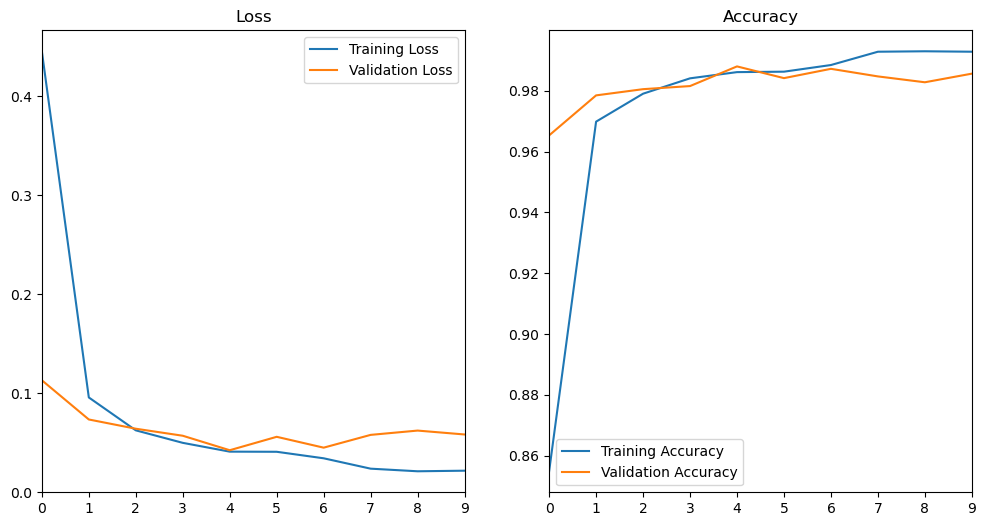

In [32]:
fig, axs = plt.subplots(ncols=2)
fig.set_size_inches(12, 6)

for i, metric in enumerate(['loss', 'accuracy']):
    axs[i].plot(history.epoch, history.history[f'{metric}'], label = f'Training {metric.title()}')
    axs[i].plot(history.epoch, history.history[f'val_{metric}'], label = f'Validation {metric.title()}')
    axs[i].legend()
    axs[i].set(title=metric.title(), xlim=(0, max(history.epoch)))

394/394 [==============================] - 2s 6ms/step


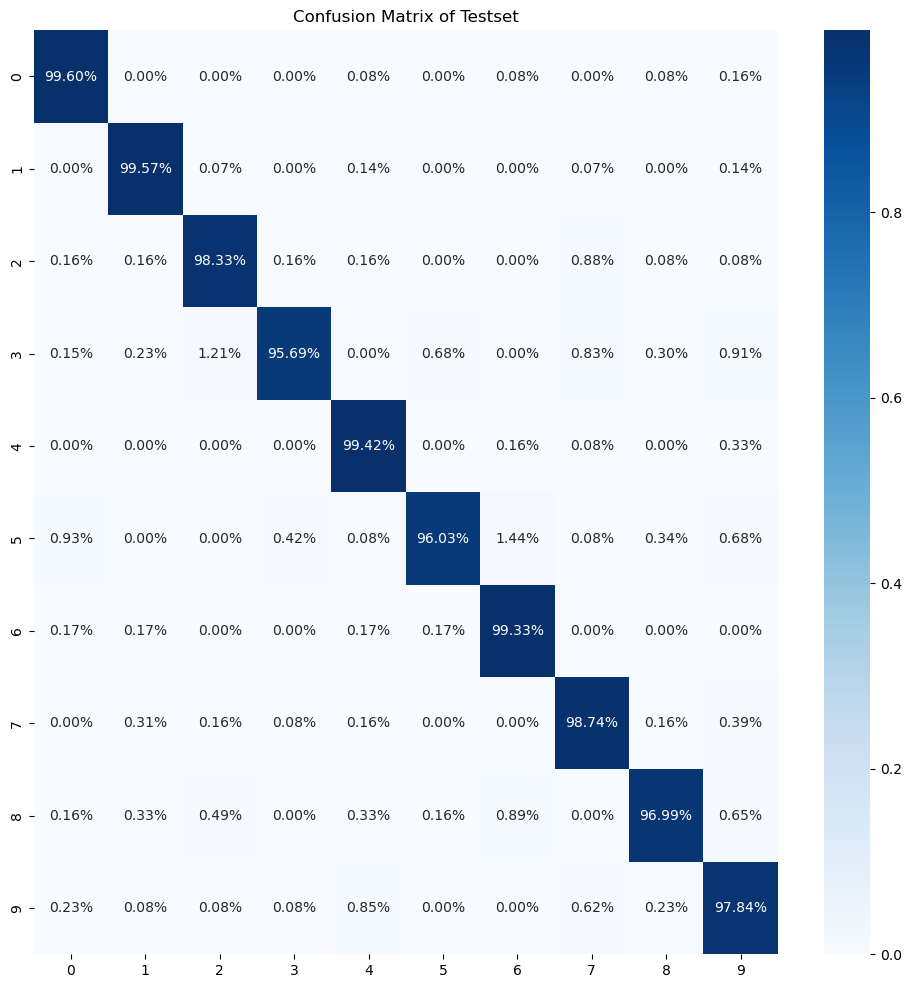

In [34]:
y_pred = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_pred, y_test, normalize='true')

fig, axs = plt.subplots()
fig.set_size_inches(12, 12)
sns.heatmap(cm, cmap='Blues', fmt='.2%', annot=True, ax=axs)
axs.set(title='Confusion Matrix of Testset')
plt.show()